# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Head and Shoulders: Entry and Exits

In the previous notebooks, you learnt how to successfully detect the presence of the head and shoulders patterns within the price data of SPY. We also saved information such as the dates and prices corresponding to the formation of the head, the shoulders and the neckline structures for each instance of the head and shoulders pattern. In this notebook, you will learn to determine the entry and exit levels to take trades based on the head and shoulders patterns.

This notebook is structured as follows:
1. [Import Libraries](#libraries)
2. [Read the Data](#data)
3. [Visualise the Head and Shoulders Pattern](#visualise)
4. [Pattern Confirmation](#confirmation)
5. [Risk Management](#risk)
6. [Conclusion and Next Steps](#conclusion)

<a id='libraries'></a>
## Import Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

# For visualisation
import mplfinance as mpf

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

<a id='data'></a>
## Read the Data

Import the file `spy_daily_1993_2018.csv` using the `read_csv` method of `pandas`. This file has the OHLCV values for SPY ETF in the daily frequency. This CSV file is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

In [2]:
# Import the stock price data
data = pd.read_csv(
    '../data_modules/spy_daily_1993_2018.csv', index_col=0)

# Change the index type to datetime
data.index = pd.to_datetime(data.index)

# Display the data
data.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2018-12-24,224.666298,226.358066,220.183133,220.248917,147311600
2018-12-26,221.780913,231.376968,219.703796,231.376968,218485400
2018-12-27,227.984041,233.360078,224.591113,233.153320,186267300
2018-12-28,234.572501,236.283055,231.630707,232.852539,153100200
2018-12-31,234.553721,235.145843,232.589398,234.892075,144299400


In the previous notebook, we had created a dataframe by the name `hs_patterns_data` which held details of every single instance of the head and shoulders patterns that was detected for SPY based on the price data. We saved all of this information into a CSV file called `hs_patterns_data.csv`. 

Let us now import the very same data so that we can backtest the head and shoulders pattern.

In [3]:
# Import the stock price data
hs_patterns_data = pd.read_csv(
    '../data_modules/hs_patterns_data.csv', index_col=0)

# Set the columns containing dates to datetime format
hs_patterns_data[['sh1_date', 'neck1_date', 'head_date', 'neck2_date', 'sh2_date']] = hs_patterns_data[[
    'sh1_date', 'neck1_date', 'head_date', 'neck2_date', 'sh2_date']].apply(pd.to_datetime, format='%Y-%m-%d')
hs_patterns_data.tail()

,sh1_date,neck1_date,head_date,neck2_date,sh2_date,sh1_price,neck1_price,head_price,neck2_price,sh2_price
4,2011-08-17,2011-08-22,2011-08-31,2011-09-12,2011-09-20,97.800056,90.707152,99.664096,92.030513,98.946809
5,2014-03-21,2014-03-27,2014-04-04,2014-04-11,2014-04-22,161.603668,157.226256,162.185033,155.011934,161.073550
6,2015-06-22,2015-07-07,2015-07-20,2015-07-27,2015-07-31,186.217163,178.789133,186.733906,180.672454,185.218543
7,2016-04-01,2016-04-07,2016-04-20,2016-05-06,2016-05-11,184.418266,180.812506,187.783649,181.515860,185.664686
8,2018-08-29,2018-09-07,2018-09-21,2018-09-26,2018-10-03,271.376965,266.698077,273.988388,270.428348,273.979057


<a id='visualise'></a>
## Visualise the Head and Shoulders Pattern

In the upcoming cells, we will perform some simple steps to visualise the head and shoulders pattern using the `mplfinance` library. We have multiple instances of the head and shoulders pattern, but, for now, let us plot one pattern at a time.

### Specify the Pattern to Plot

In the below cell, we have set the `pattern_index` as `1` and this will help us visualise the sixth head and shoulders instance that was detected in the data. However, feel free to change this value if you wish to plot a different head and shoulders instance.

In [4]:
# Specify the pattern index
pattern_index = 1

# Initialise the pattern data
hs_patterns_to_plot = hs_patterns_data.iloc[pattern_index]
points = int(len(hs_patterns_to_plot)/2)

# Capture the pattern details for the most recent pattern
hs = pd.DataFrame()
hs['dates'] = hs_patterns_to_plot.iloc[:points]
hs['price'] = hs_patterns_to_plot.iloc[points:].values
hs

,dates,price
sh1_date,2001-05-02 00:00:00,85.175419
neck1_date,2001-05-04 00:00:00,82.3405
head_date,2001-05-22 00:00:00,88.110491
neck2_date,2001-05-30 00:00:00,83.381106
sh2_date,2001-06-05 00:00:00,86.202712


### Get the OHLCV Data Corresponding to the Period

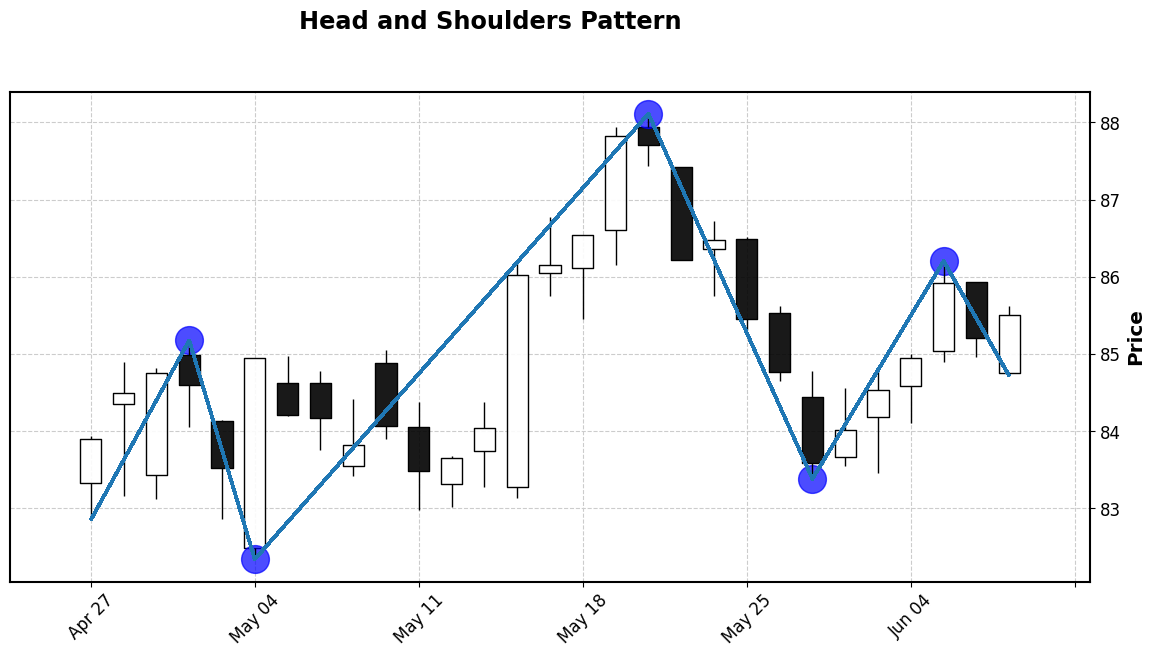

In [5]:
# Initialise the start and end dates for OHLCV data
start_index = data.index.get_loc(hs.dates[0]) - 3
last_index = data.index.get_loc(hs.dates[-1]) + 3

# Fetch the OHLCV data for the period
data_to_plot = data.iloc[start_index:last_index]

# Add pattern details to data_to_plot
data_to_plot['pattern'] = np.nan
data_to_plot.loc[hs.dates, 'pattern'] = hs.price.values

# Define scatter plot to mark the 5 sequential points forming the pattern
hs_plot = mpf.make_addplot(data_to_plot.pattern, type='scatter', marker='o', markersize=400,
                           panel=0, color="blue", alpha=0.7)

# Define subplot of a line that will connect the 5 sequential points
pattern_line = [(data_to_plot.index[0], data.iloc[start_index:data.index.get_loc(hs.dates[0])].min()['Low'])] + list(hs.itertuples(
    index=False, name=None)) + [(data_to_plot.index[-1], data.iloc[data.index.get_loc(hs.dates[-1]):last_index].min()['Low'])]

# Plot the candlestick chart along with pattern-related subplots
mpf.plot(data_to_plot, type='candle', style='classic', addplot=hs_plot,
         title='Head and Shoulders Pattern', figsize=(15, 7), alines=pattern_line)

As you can see in the above graph, we have successfully identified a head and shoulders pattern based on the OHLCV data. 

<a id='confirmation'></a>
## Pattern Confirmation

You have learnt in the previous video units that a head and shoulders pattern is completed only after the recent shoulder breaks below the neckline. However, sometimes, the pattern may not be able to return back to the neckline. Hence, it is necessary for us to also capture the confirmation date for every head and shoulder pattern.

### Get the Confirmation Date

Ideally, a head and shoulders pattern is confirmed once a candle closes below the neckline of the pattern. But for ease of implementation in Python, we can say that a head and shoulders pattern is confirmed if the prices, after the formation of the second shoulder, end up closing below the second point of the neckline i.e. `neck2_price`. 

In [6]:
# Function to fetch pattern confirmation date
def get_confirmation_date(hs_patterns, data=data):

    # Initialise data after the formation of shoulder2
    data_after_sh2 = data.loc[hs_patterns.sh2_date:].Close
    try:
        # Capture the date if prices were able to close below the neckline
        return data_after_sh2[data_after_sh2 < hs_patterns.neck2_price].index[0]
    except:
        # Assign NaN if prices were not able to close below the neckline
        return np.nan

# Store the information for confirmation with the rest of the pattern data
hs_patterns_data['confirmation_date'] = hs_patterns_data.apply(
    get_confirmation_date, axis=1)

### Check the Time Taken Until Confirmation

The code in the below cell filters the head and shoulders patterns based on two conditions: 
1) The `time_for_confirmation` must be more than 5 bars away to avoid look-ahead bias<br>
This ensures that trades are not taken before the pattern is completely formed.

2) The `time_for_confirmation` must occur within 30 bars<br>
This ensures that the pattern is not occurring over an excessively long duration, as generally such patterns would not qualify as good head and shoulders patterns. 

The result is a subset of the data that meets both conditions and represents valid head and shoulders patterns where we can take trades.

In [7]:
# Drop NaN values from 'hs_patterns_data'
hs_patterns_data.dropna(inplace=True)

# Store the number of days taken to generate a short entry date in the column 'time_for_confirmation'
hs_patterns_data['time_for_confirmation'] = (
    hs_patterns_data.confirmation_date - hs_patterns_data.sh2_date).dt.days

# Selecting the patterns that represent head and shoulders patterns that can be traded
hs_patterns_data[(hs_patterns_data['time_for_confirmation'] > 5) & (
    hs_patterns_data['time_for_confirmation'] < 30)]
hs_patterns_data['signal'] = -1
hs_patterns_data = hs_patterns_data.reset_index(drop=True)
hs_patterns_data.tail()

,sh1_date,neck1_date,head_date,neck2_date,sh2_date,sh1_price,neck1_price,head_price,neck2_price,sh2_price,confirmation_date,time_for_confirmation,signal
3,2005-12-14,2005-12-30,2006-01-11,2006-01-25,2006-01-30,91.920951,89.717330,93.382150,90.785015,92.927670,2006-02-07,8,-1
4,2011-08-17,2011-08-22,2011-08-31,2011-09-12,2011-09-20,97.800056,90.707152,99.664096,92.030513,98.946809,2011-09-22,2,-1
5,2015-06-22,2015-07-07,2015-07-20,2015-07-27,2015-07-31,186.217163,178.789133,186.733906,180.672454,185.218543,2015-08-20,20,-1
6,2016-04-01,2016-04-07,2016-04-20,2016-05-06,2016-05-11,184.418266,180.812506,187.783649,181.515860,185.664686,2016-06-27,47,-1
7,2018-08-29,2018-09-07,2018-09-21,2018-09-26,2018-10-03,271.376965,266.698077,273.988388,270.428348,273.979057,2018-10-05,2,-1


### Visualise the Head and Shoulders Breakdown

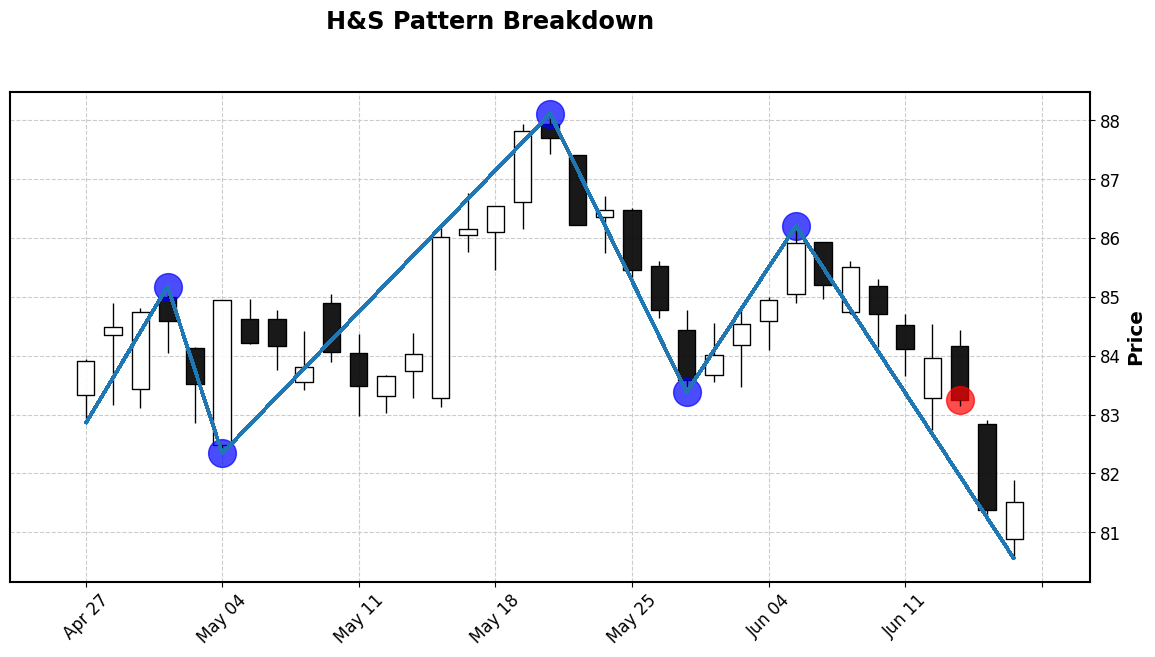

In [8]:
# Select the pattern data
hs_patterns_to_plot = hs_patterns_data.iloc[pattern_index]
hs['dates'] = hs_patterns_to_plot.iloc[:points]
hs['price'] = hs_patterns_to_plot.iloc[points:2*points].values

# Define the start and end date of the pattern to plot
start_index = data.index.get_loc(hs.dates[0]) - 3
last_index = data.index.get_loc(hs_patterns_to_plot.confirmation_date) + 3

# Select the data of the pattern to plot
data_to_plot = data.iloc[start_index:last_index]
data_to_plot['pattern'] = np.nan
data_to_plot.loc[hs.dates, 'pattern'] = hs.price.values

# Define 'pattern_line' to draw the pattern
pattern_line = [(data_to_plot.index[0], data.iloc[start_index:data.index.get_loc(hs.dates[0])].min()['Low'])] + list(hs.itertuples(
    index=False, name=None)) + [(data_to_plot.index[-1], data.iloc[data.index.get_loc(hs.dates[-1]):last_index].min()['Low'])]

# Define a list of markets and store in 'hs_plot'
hs_plot = [mpf.make_addplot(data_to_plot.pattern, type='scatter', marker='o', markersize=400,
                            panel=0, color="blue", alpha=0.7)]
data_to_plot['trade'] = np.nan
data_to_plot.loc[hs_patterns_to_plot.confirmation_date,
                 'trade'] = data_to_plot.loc[hs_patterns_to_plot.confirmation_date, 'Close']
hs_plot += [mpf.make_addplot(data_to_plot.trade, type='scatter', marker='o', markersize=400,
                             panel=0, color="red", alpha=0.7)]

# Plot the candlestick plot, line plot and markers representing the selected pattern
mpf.plot(data_to_plot, type='candle', style='classic', addplot=hs_plot,
         title='H&S Pattern Breakdown', figsize=(15, 7), alines=pattern_line)

<a id='risk'></a>
# Risk Management

Another important aspect that you need to take into consideration involves setting the exit levels for each pattern. This includes setting the stop-loss and target levels based on each pattern.

### Determine the Exit Levels

For the head and shoulders pattern, we will set the exit levels in the following manner:
1. Stop-loss: Set just above the second shoulder.

2. Target: Set at a fixed distance below the entry price. The distance can be a multiple of the difference between the highest point (head) and the second point of the neckline (neck2). Here we have taken a multiple of 5.

In [9]:
# Set stop-loss 0.1% above the right shoulder
hs_patterns_data['stoploss'] = hs_patterns_data['sh2_price']*1.001

# Calculate the distance between the head and the neckline
hs_patterns_data['head_length'] = hs_patterns_data['head_price'] - \
    hs_patterns_data['neck2_price']

# Set target at a distance of head_length below the neckline
hs_patterns_data['target'] = hs_patterns_data['neck2_price'] - \
    5 * hs_patterns_data['head_length']

# Display dataframe
hs_patterns_data.tail()

,sh1_date,neck1_date,head_date,neck2_date,sh2_date,sh1_price,neck1_price,head_price,neck2_price,sh2_price,confirmation_date,time_for_confirmation,signal,stoploss,head_length,target
3,2005-12-14,2005-12-30,2006-01-11,2006-01-25,2006-01-30,91.920951,89.717330,93.382150,90.785015,92.927670,2006-02-07,8,-1,93.020598,2.597135,77.799338
4,2011-08-17,2011-08-22,2011-08-31,2011-09-12,2011-09-20,97.800056,90.707152,99.664096,92.030513,98.946809,2011-09-22,2,-1,99.045756,7.633583,53.862596
5,2015-06-22,2015-07-07,2015-07-20,2015-07-27,2015-07-31,186.217163,178.789133,186.733906,180.672454,185.218543,2015-08-20,20,-1,185.403762,6.061453,150.365190
6,2016-04-01,2016-04-07,2016-04-20,2016-05-06,2016-05-11,184.418266,180.812506,187.783649,181.515860,185.664686,2016-06-27,47,-1,185.850351,6.267789,150.176914
7,2018-08-29,2018-09-07,2018-09-21,2018-09-26,2018-10-03,271.376965,266.698077,273.988388,270.428348,273.979057,2018-10-05,2,-1,274.253036,3.560040,252.628150


### Visualise the Exit Levels

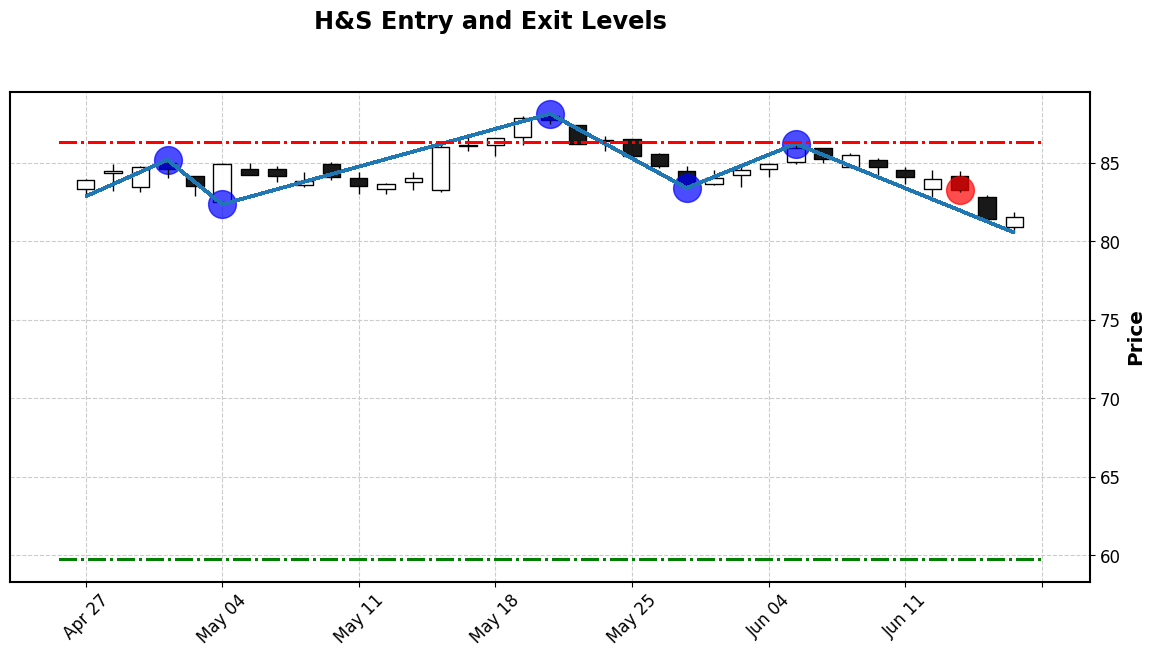

In [10]:
# Select the pattern to plot
hs_patterns_to_plot = hs_patterns_data.iloc[pattern_index]

# Visualise the candlestick plot of the pattern along with stop-loss and profit target
mpf.plot(data_to_plot, type='candle', style='classic', addplot=hs_plot,
         title='H&S Entry and Exit Levels', figsize=(15, 7), alines=pattern_line,
         hlines=dict(hlines=[hs_patterns_to_plot.target, hs_patterns_to_plot.stoploss],
                     colors=['g', 'r'], linestyle='-.'))

The confirmation date has been marked as a red spot. This is the date when a candle closed below the second neckline point indicating a clear breakdown. And the two horizontal lines (red and green) in the above plot represent the exit levels, i.e. the stop-loss and the target levels respectively. 

The stop-loss level has been marked in red and lies above the peak of the right shoulder. And lastly, the target level has been placed below the entry level, at the same distance as the head from the neckline.

<a id='conclusion'></a>
## Conclusion and Next Steps


You will need the data present in the dataframe `trade_details` to further backtest the head and shoulders strategy. For this, you can simply you can update the following cell's type to **Code** and run the code line, in order to save the data into a CSV file named `hs_trade_setups.csv`.

In the upcoming Jupyter notebook, you will learn to backtest the head and shoulders patterns and check the trade logs. <br><br>